# 🚗 Personalized Automobile Recommendation System
**JIIT Noida — AIML Lab**  
Team: Mohd Kashif Khan · Harshita Singhal · Ashmi Verma · Vanshik Jain  
Submitted to: Ms. Ambalika Sarkar

---
## Contents
1. EDA & Pandas/NumPy Showcase
2. Feature Engineering
3. KNN Recommender
4. Price Prediction — 3-Model Comparison (Linear Regression · Decision Tree · Random Forest)
5. PCA Visualisation
6. Collaborative Filtering (Simulated Persona Profiles)
7. Save Artefacts

## 1. EDA & Pandas/NumPy Showcase
Covers coursework point 1 — deliberate use of NumPy and Pandas for data exploration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')

df_raw = pd.read_csv('../data/cars.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (5975, 14)


,Unnamed: 0,Name,Manufacturer,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine CC,Power,Seats,Mileage Km/L,Price
0,0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,72000,CNG,Manual,First,998,58.16,5,26.60,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,41000,Diesel,Manual,First,1582,126.20,5,19.67,12.50
2,2,Honda Jazz V,Honda,Chennai,2011,46000,Petrol,Manual,First,1199,88.70,5,18.20,4.50
3,3,Maruti Ertiga VDI,Maruti,Chennai,2012,87000,Diesel,Manual,First,1248,88.76,7,20.77,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,40670,Diesel,Automatic,Second,1968,140.80,5,15.20,17.74


In [2]:
# ── 1a. Basic info ────────────────────────────────────────────────────────────
print('Columns:', df_raw.columns.tolist())
print('\nNull counts:')
print(df_raw.isnull().sum())
print('\nData types:')
print(df_raw.dtypes)

Columns: ['Unnamed: 0', 'Name', 'Manufacturer', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine CC', 'Power', 'Seats', 'Mileage Km/L', 'Price']

Null counts:
Unnamed: 0           0
Name                 0
Manufacturer         0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Engine CC            0
Power                0
Seats                0
Mileage Km/L         0
Price                0
dtype: int64

Data types:
Unnamed: 0             int64
Name                  object
Manufacturer          object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Engine CC              int64
Power                float64
Seats                  int64
Mileage Km/L         float64
Price                float64
dtype: object


In [ ]:
numeric_cols = ['Engine CC', 'Power', 'Seats', 'Mileage Km/L', 'Price',
                'Kilometers_Driven', 'Year']
arr = df_raw[numeric_cols].dropna().values   # pure NumPy array

print('NumPy-computed statistics on numeric columns:')
print(f'  Shape      : {arr.shape}')
print(f'  Mean Price : ₹{np.mean(arr[:, 4]):.2f}L')
print(f'  Std  Price : ₹{np.std(arr[:, 4]):.2f}L')
print(f'  Median KM  : {np.median(arr[:, 5]):,.0f} km')
print(f'  75th pctl  : {np.percentile(arr[:, 4], 75):.2f}L')
print(f'  Correlation (Engine CC vs Price): {np.corrcoef(arr[:,0], arr[:,4])[0,1]:.3f}')
print(f'  Correlation (Age vs Price):       '
      f'{np.corrcoef(2024 - arr[:,6], arr[:,4])[0,1]:.3f}')

NumPy-computed statistics on numeric columns:
  Shape      : (5975, 7)
  Mean Price : ₹9.50L
  Std  Price : ₹11.20L
  Median KM  : 53,000 km
  75th pctl  : 9.95L
  Correlation (Engine CC vs Price): 0.659
  Correlation (Age vs Price):       -0.306


In [ ]:
print('=== Top 10 Brands by listing count ===')
print(df_raw['Manufacturer'].value_counts().head(10).to_string())

print('\n=== Fuel Type distribution ===')
print(df_raw['Fuel_Type'].value_counts().to_string())

print('\n=== Average Price by Fuel Type ===')
print(df_raw.groupby('Fuel_Type')['Price'].agg(['mean','median','count']).round(2).to_string())

=== Top 10 Brands by listing count ===
Manufacturer
Maruti          1197
Hyundai         1100
Honda            601
Toyota           409
MercedesBenz     318
Volkswagen       315
Ford             298
Mahindra         271
BMW              262
Audi             236

=== Fuel Type distribution ===
Fuel_Type
Diesel    3195
Petrol    2714
CNG         56
LPG         10

=== Average Price by Fuel Type ===
            mean  median  count
Fuel_Type                      
CNG         3.52    3.25     56
Diesel     12.84    7.75   3195
LPG         2.49    2.60     10
Petrol      5.72    4.15   2714


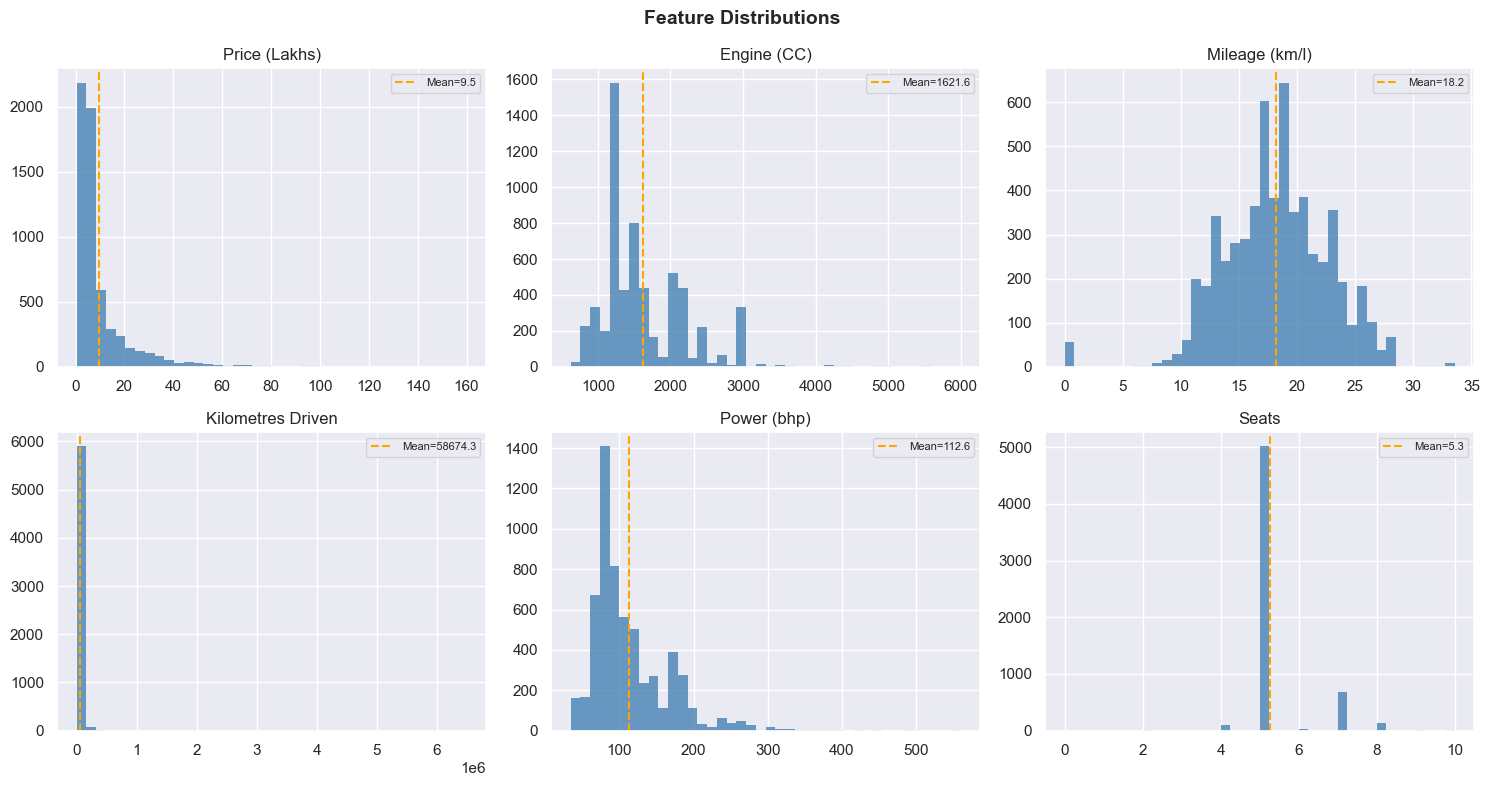

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

plot_data = [
    ('Price',             'Price (Lakhs)',       axes[0,0]),
    ('Engine CC',         'Engine (CC)',          axes[0,1]),
    ('Mileage Km/L',      'Mileage (km/l)',       axes[0,2]),
    ('Kilometers_Driven', 'Kilometres Driven',    axes[1,0]),
    ('Power',             'Power (bhp)',          axes[1,1]),
    ('Seats',             'Seats',                axes[1,2]),
]

for col, label, ax in plot_data:
    data = df_raw[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(data.mean(), color='orange', linewidth=1.5, linestyle='--', label=f'Mean={data.mean():.1f}')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

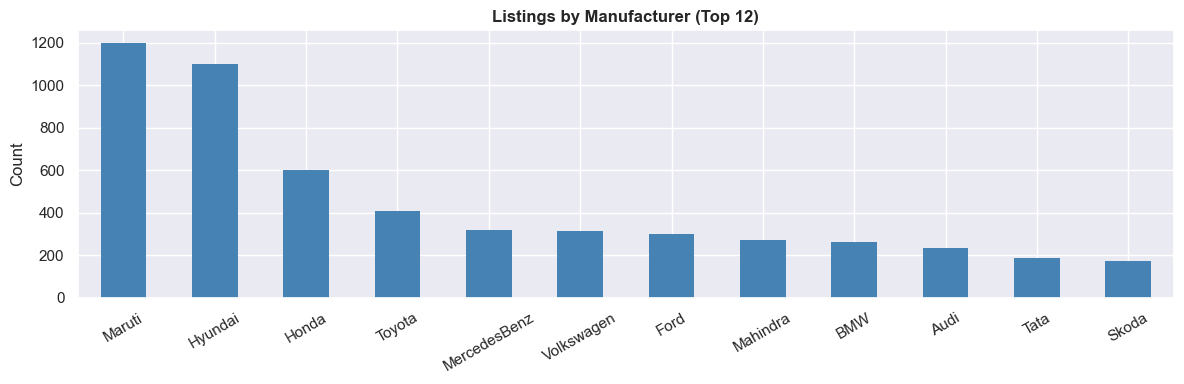

In [ ]:
brand_counts = df_raw['Manufacturer'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 4))
brand_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Listings by Manufacturer (Top 12)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

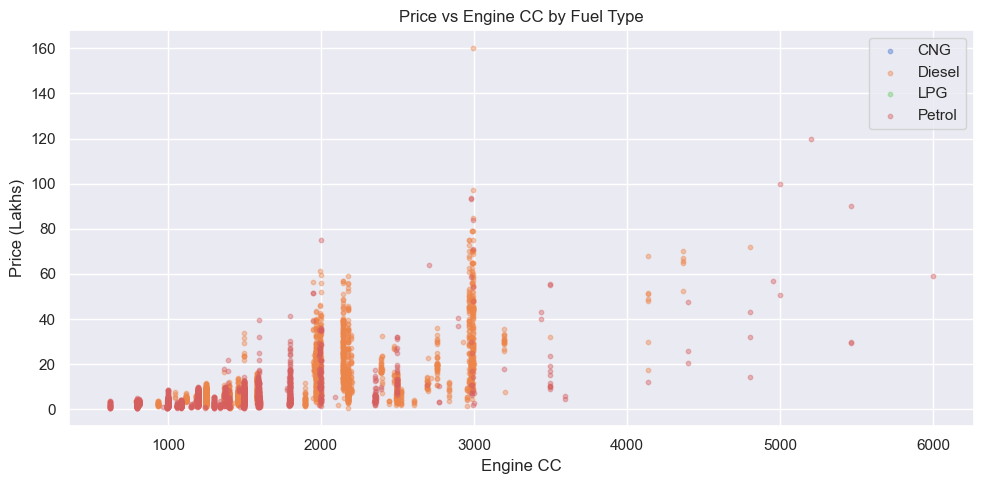

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for fuel, grp in df_raw.groupby('Fuel_Type'):
    ax.scatter(grp['Engine CC'], grp['Price'], alpha=0.4, s=10, label=fuel)
ax.set_xlabel('Engine CC')
ax.set_ylabel('Price (Lakhs)')
ax.set_title('Price vs Engine CC by Fuel Type')
ax.legend()
plt.tight_layout()
plt.show()

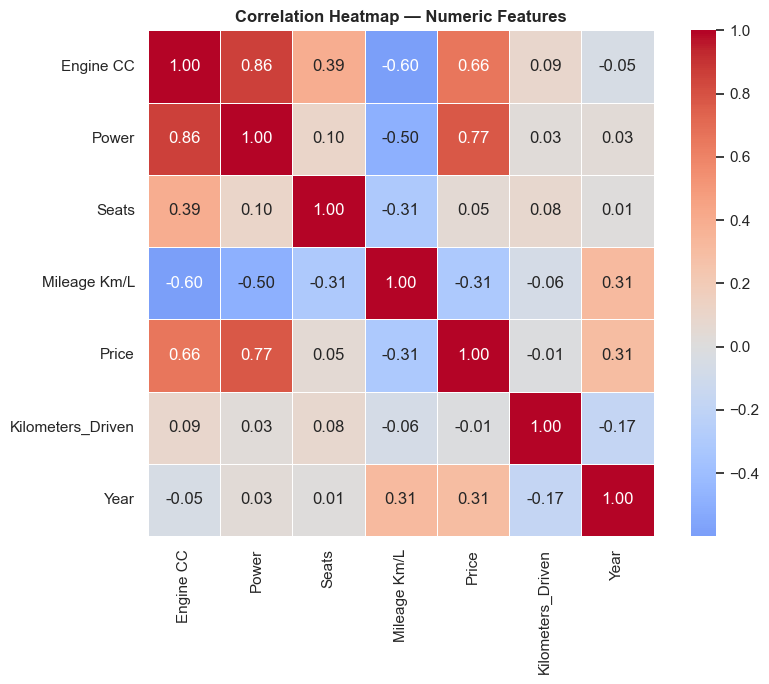

NumPy corrcoef (Engine CC vs Price): 0.659


In [ ]:
corr_cols = ['Engine CC', 'Power', 'Seats', 'Mileage Km/L',
             'Price', 'Kilometers_Driven', 'Year']
corr_matrix = df_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

print('NumPy corrcoef (Engine CC vs Price):',
      np.corrcoef(df_raw['Engine CC'].dropna(), df_raw.loc[df_raw['Engine CC'].notna(), 'Price'])[0,1].round(3))

## 2. Feature Engineering
Covers coursework point 2 — data preparation.  
We add four new features from columns that the v1 notebook ignored:
- **Car_Age** = 2024 − Year
- **Usage_Intensity** = Kilometers_Driven / Car_Age
- **Owner_Type_Enc** (ordinal: First=1, Second=2, …)
- **Power** (already in CSV, not used before)
- **Location_Enc** (city encoded as integer)

In [ ]:
df = df_raw.copy()
df = df.rename(columns={'Engine CC': 'Engine(CC)', 'Mileage Km/L': 'Mileage(Km/L)'})

df = df[df['Fuel_Type'] != 'LPG']

df['Manufacturer'] = df['Manufacturer'].str.title()

core_cols = ['Name','Manufacturer','Fuel_Type','Transmission',
             'Engine(CC)','Mileage(Km/L)','Seats','Price']
df = df.dropna(subset=core_cols)
df = df[df['Seats'] <= 7].reset_index(drop=True)

print(f'Clean dataset shape: {df.shape}')
df.head(3)

Clean dataset shape: (5823, 14)


,Unnamed: 0,Name,Manufacturer,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine(CC),Power,Seats,Mileage(Km/L),Price
0,0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,72000,CNG,Manual,First,998,58.16,5,26.60,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,41000,Diesel,Manual,First,1582,126.20,5,19.67,12.50
2,2,Honda Jazz V,Honda,Chennai,2011,46000,Petrol,Manual,First,1199,88.70,5,18.20,4.50


In [ ]:
REFERENCE_YEAR = 2024

df['Car_Age'] = (REFERENCE_YEAR - df['Year']).clip(lower=1)

df['Usage_Intensity'] = df['Kilometers_Driven'] / df['Car_Age']

OWNER_MAP = {'First': 1, 'Second': 2, 'Third': 3, 'Fourth & Above': 4}
df['Owner_Type_Enc'] = df['Owner_Type'].map(OWNER_MAP).fillna(3).astype(int)

FUEL_MAP  = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'Electric': 3}
TRANS_MAP = {'Manual': 0, 'Automatic': 1}
df['Fuel_Type_Enc']    = df['Fuel_Type'].map(FUEL_MAP).fillna(0).astype(int)
df['Transmission_Enc'] = df['Transmission'].map(TRANS_MAP).fillna(0).astype(int)

locations  = sorted(df['Location'].dropna().unique())
loc_map    = {loc: i for i, loc in enumerate(locations)}
df['Location_Enc'] = df['Location'].map(loc_map).fillna(0).astype(int)

df['Power'] = pd.to_numeric(df['Power'], errors='coerce')
df['Power'].fillna(df['Power'].median(), inplace=True)

print('New features added:')
print(df[['Name','Car_Age','Usage_Intensity','Owner_Type_Enc','Power','Location_Enc']].head())

New features added:
                               Name  Car_Age  Usage_Intensity  Owner_Type_Enc  \
0            Maruti Wagon R LXI CNG       14      5142.857143               1   
1  Hyundai Creta 1.6 CRDi SX Option        9      4555.555556               1   
2                      Honda Jazz V       13      3538.461538               1   
3                 Maruti Ertiga VDI       12      7250.000000               1   
4   Audi A4 New 2.0 TDI Multitronic       11      3697.272727               2   

    Power  Location_Enc  
0   58.16             9  
1  126.20            10  
2   88.70             2  
3   88.76             2  
4  140.80             3  


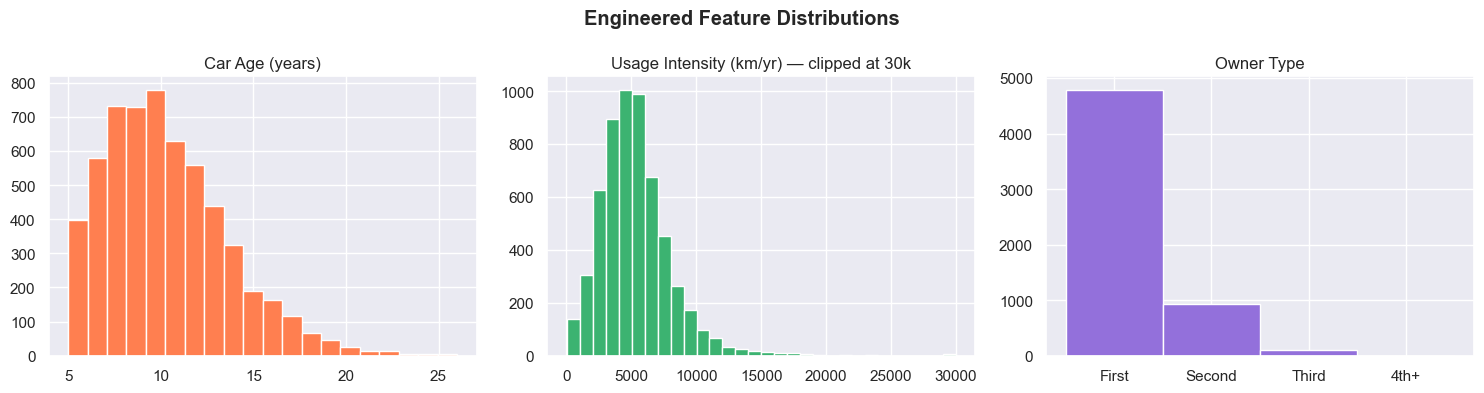

Correlation of new features with Price:
Car_Age           -0.302
Usage_Intensity    0.050
Owner_Type_Enc    -0.095
Power              0.773
Location_Enc      -0.119


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Engineered Feature Distributions', fontweight='bold')

axes[0].hist(df['Car_Age'], bins=20, color='coral')
axes[0].set_title('Car Age (years)')

axes[1].hist(df['Usage_Intensity'].clip(upper=30000), bins=30, color='mediumseagreen')
axes[1].set_title('Usage Intensity (km/yr) — clipped at 30k')

axes[2].hist(df['Owner_Type_Enc'], bins=[0.5,1.5,2.5,3.5,4.5],
             color='mediumpurple', edgecolor='white')
axes[2].set_xticks([1,2,3,4])
axes[2].set_xticklabels(['First','Second','Third','4th+'])
axes[2].set_title('Owner Type')

plt.tight_layout()
plt.show()

new_feats = ['Car_Age','Usage_Intensity','Owner_Type_Enc','Power','Location_Enc']
print('Correlation of new features with Price:')
print(df[new_feats + ['Price']].corr()['Price'].drop('Price').round(3).to_string())

## 3. KNN Recommender
Uses the full enriched feature set.  
The model finds the k nearest neighbours in scaled feature space for a given user preference vector.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

FEATURE_COLS    = ['Manufacturer','Fuel_Type','Transmission',
                   'Engine(CC)','Mileage(Km/L)','Seats','Price']
CATEGORICAL_COLS = ['Manufacturer','Fuel_Type','Transmission']

X = df[FEATURE_COLS].copy()
X = pd.get_dummies(X, columns=CATEGORICAL_COLS)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f'KNN feature matrix shape: {X_scaled.shape}')
X_scaled_df.head()

KNN feature matrix shape: (5823, 39)


,Engine(CC),Mileage(Km/L),Seats,Price,Manufacturer_Ambassador,Manufacturer_Audi,Manufacturer_Bentley,Manufacturer_Bmw,Manufacturer_Chevrolet,Manufacturer_Datsun,...,Manufacturer_Smart,Manufacturer_Tata,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
0,0.069594,0.793083,0.714286,0.008210,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.178266,0.586464,0.714286,0.075583,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.106997,0.542636,0.714286,0.025445,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.116115,0.619261,1.000000,0.034846,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.250093,0.453190,0.714286,0.108423,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
knn_model = NearestNeighbors(n_neighbors=10, metric='euclidean', algorithm='ball_tree')
knn_model.fit(X_scaled)
print(f'KNN model trained on {X_scaled.shape[0]:,} samples with {X_scaled.shape[1]} features')

KNN model trained on 5,823 samples with 39 features


In [ ]:
def recommend_knn_nb(user_input, df, model, scaler, knn_columns, n=5):
    """
    Notebook version of the KNN recommender.
    Returns top-n recommended cars with confidence scores.
    """
    user_df = pd.DataFrame([user_input])
    user_df = pd.get_dummies(user_df)
    user_df = user_df.reindex(columns=knn_columns, fill_value=0)
    user_vec = scaler.transform(user_df)

    pool = min(len(df), max(50, n * 10))
    dists, idxs = model.kneighbors(user_vec, n_neighbors=pool)

    fdf = df.copy()
    for col, key in [('Manufacturer','Manufacturer'),('Fuel_Type','Fuel_Type'),
                     ('Transmission','Transmission')]:
        val = user_input.get(key)
        if val:
            cand = fdf[fdf[col] == val]
            if not cand.empty:
                fdf = cand
    fset = set(fdf.index)

    valid = [(i, d) for i, d in zip(idxs[0], dists[0]) if i in fset]
    if not valid:
        valid = list(zip(idxs[0][:n], dists[0][:n]))

    res_idx  = [p[0] for p in valid[:n]]
    res_dist = [p[1] for p in valid[:n]]

    result = df.iloc[res_idx].copy()
    result['Distance']   = res_dist
    result['Confidence'] = result['Distance'].apply(
        lambda d: round(max(0, 1 - d / 3.0) * 100, 1)
    )
    return result[['Name','Price','Fuel_Type','Transmission',
                   'Engine(CC)','Mileage(Km/L)','Seats',
                   'Distance','Confidence']].reset_index(drop=True)


user_input_knn = {
    'Manufacturer':  'Maruti',
    'Fuel_Type':     'Petrol',
    'Transmission':  'Manual',
    'Engine(CC)':    1200,
    'Mileage(Km/L)': 20.0,
    'Seats':         5,
    'Price':         5.0,
}

knn_results = recommend_knn_nb(user_input_knn, df, knn_model, scaler, X.columns, n=5)
print('Top 5 KNN Recommendations:')
knn_results

Top 5 KNN Recommendations:


,Name,Price,Fuel_Type,Transmission,Engine(CC),Mileage(Km/L),Seats,Distance,Confidence
0,Maruti Swift VXI BSIV,5.00,Petrol,Manual,1197,20.4,5,0.011939,99.6
1,Maruti Swift ZXI,4.95,Petrol,Manual,1197,20.4,5,0.011943,99.6
2,Maruti Swift VXI BSIV,5.15,Petrol,Manual,1197,20.4,5,0.011976,99.6
3,Maruti Swift VXI BSIV,5.20,Petrol,Manual,1197,20.4,5,0.012005,99.6
4,Maruti Swift VXI Optional,5.27,Petrol,Manual,1197,20.4,5,0.012058,99.6


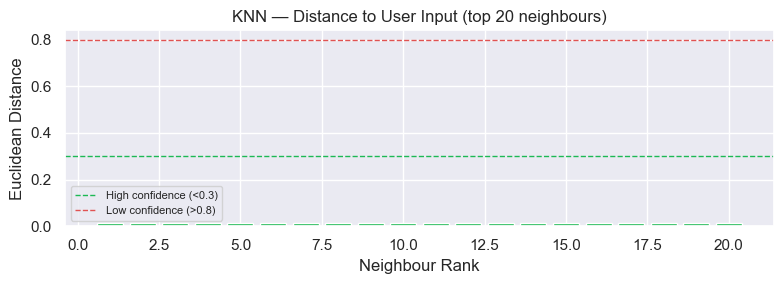

In [ ]:
user_df_eval = pd.DataFrame([user_input_knn])
user_df_eval = pd.get_dummies(user_df_eval)
user_df_eval = user_df_eval.reindex(columns=X.columns, fill_value=0)
user_vec_eval = scaler.transform(user_df_eval)

distances_all, _ = knn_model.kneighbors(user_vec_eval, n_neighbors=20)
dists = distances_all[0]

fig, ax = plt.subplots(figsize=(8, 3))
colors = ['#1db954' if d < 0.3 else ('#f0a500' if d < 0.8 else '#e05252') for d in dists]
ax.bar(range(1, len(dists)+1), dists, color=colors)
ax.axhline(0.3, color='#1db954', linestyle='--', linewidth=1, label='High confidence (<0.3)')
ax.axhline(0.8, color='#e05252', linestyle='--', linewidth=1, label='Low confidence (>0.8)')
ax.set_xlabel('Neighbour Rank')
ax.set_ylabel('Euclidean Distance')
ax.set_title('KNN — Distance to User Input (top 20 neighbours)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Price Prediction — 3-Model Comparison
Covers the core ML coursework requirement: Linear Regression · Decision Tree · Random Forest.  
All three are trained and evaluated with MAE, RMSE, and R².

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RF_FEATURE_COLS = [
    'Engine(CC)', 'Mileage(Km/L)', 'Seats', 'Power',
    'Car_Age', 'Usage_Intensity', 'Owner_Type_Enc',
    'Fuel_Type_Enc', 'Transmission_Enc', 'Location_Enc',
]

available = [c for c in RF_FEATURE_COLS if c in df.columns]
X_rf = df[available].fillna(0)
y_rf = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Test  size : {X_test.shape[0]:,}')
print(f'Features   : {X_train.shape[1]}')

Train size : 4,658
Test  size : 1,165
Features   : 10


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=150, max_depth=12,
                                                random_state=42, n_jobs=-1),
}

results_price = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    results_price[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'preds': preds}
    print(f'{name:<22}  MAE={mae:.2f}L   RMSE={rmse:.2f}L   R²={r2:.4f}')

Linear Regression       MAE=3.67L   RMSE=5.93L   R²=0.7209
Decision Tree           MAE=2.08L   RMSE=4.81L   R²=0.8163
Random Forest           MAE=1.55L   RMSE=3.62L   R²=0.8958


In [ ]:
comparison_df = pd.DataFrame({
    name: {'MAE (Lakhs)': v['MAE'], 'RMSE (Lakhs)': v['RMSE'], 'R²': v['R²']}
    for name, v in results_price.items()
}).T.round(4)

print('=== Price Prediction Model Comparison ===')
comparison_df

=== Price Prediction Model Comparison ===


,MAE (Lakhs),RMSE (Lakhs),R²
Linear Regression,3.6727,5.9308,0.7209
Decision Tree,2.0824,4.8116,0.8163
Random Forest,1.5528,3.6239,0.8958


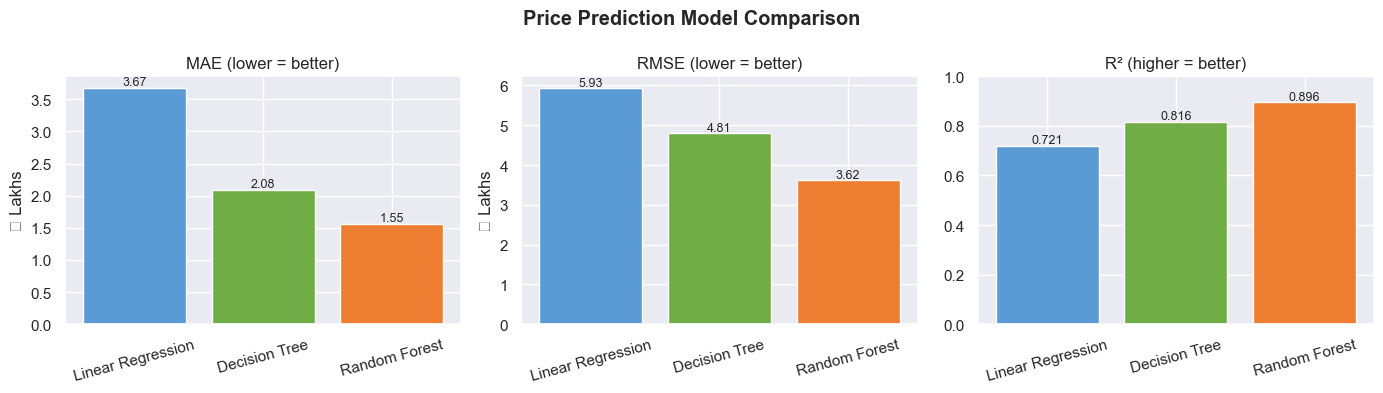

In [ ]:
model_names = list(results_price.keys())
maes  = [results_price[m]['MAE']  for m in model_names]
r2s   = [results_price[m]['R²']   for m in model_names]
rmses = [results_price[m]['RMSE'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Price Prediction Model Comparison', fontweight='bold')

colors = ['#5b9bd5', '#70ad47', '#ed7d31']

axes[0].bar(model_names, maes, color=colors)
axes[0].set_title('MAE (lower = better)')
axes[0].set_ylabel('₹ Lakhs')
for i, v in enumerate(maes): axes[0].text(i, v+0.05, f'{v:.2f}', ha='center', fontsize=9)

axes[1].bar(model_names, rmses, color=colors)
axes[1].set_title('RMSE (lower = better)')
axes[1].set_ylabel('₹ Lakhs')
for i, v in enumerate(rmses): axes[1].text(i, v+0.05, f'{v:.2f}', ha='center', fontsize=9)

axes[2].bar(model_names, r2s, color=colors)
axes[2].set_title('R² (higher = better)')
axes[2].set_ylim(0, 1)
for i, v in enumerate(r2s): axes[2].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

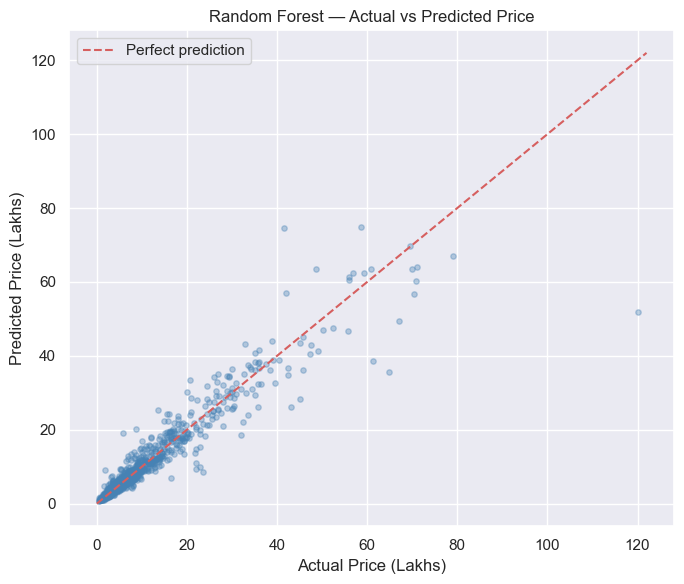

In [ ]:
rf_preds = results_price['Random Forest']['preds']

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, rf_preds, alpha=0.35, s=15, color='steelblue')
lim = max(y_test.max(), rf_preds.max()) + 2
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (Lakhs)')
ax.set_ylabel('Predicted Price (Lakhs)')
ax.set_title('Random Forest — Actual vs Predicted Price')
ax.legend()
plt.tight_layout()
plt.show()

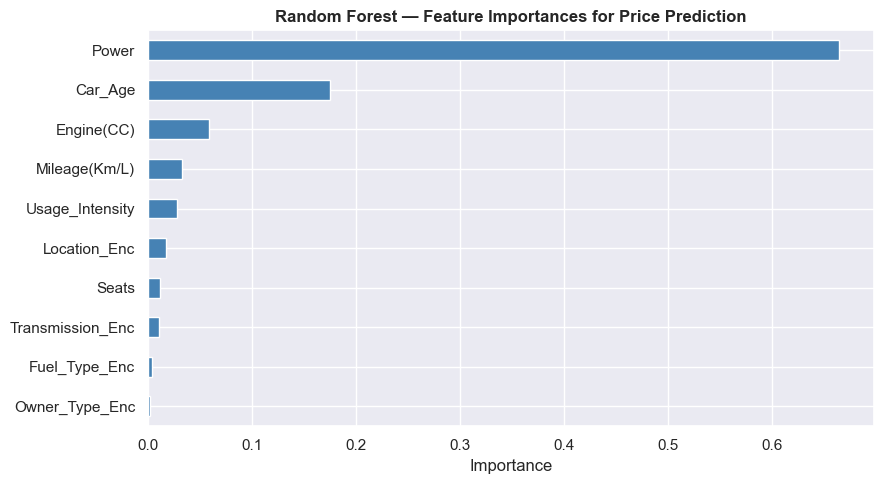

Top 3 most important features for price prediction:
  Power: 0.6651
  Car_Age: 0.1744
  Engine(CC): 0.0586


In [ ]:
rf_model = models['Random Forest']
fi = pd.Series(rf_model.feature_importances_, index=available).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances for Price Prediction', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 3 most important features for price prediction:')
for feat, imp in fi.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {imp:.4f}')

## 5. PCA Visualisation
Project the high-dimensional feature space into 2D.  
The user's query is plotted as ⭐ among the car cloud.

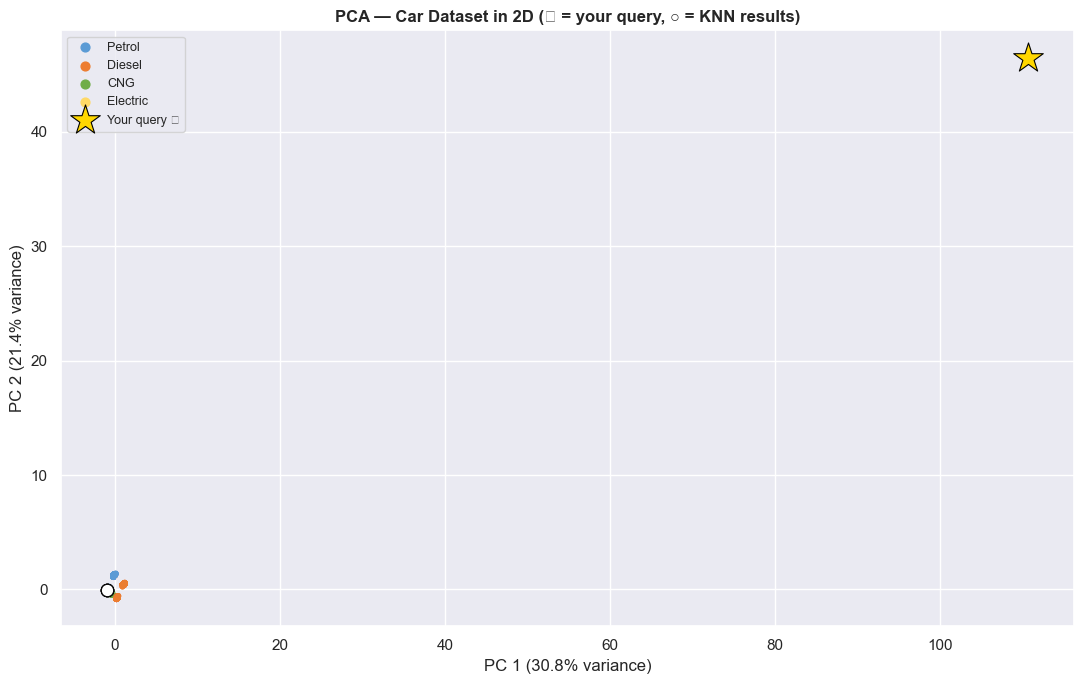

Total variance explained by 2 components: 52.2%


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

user_vec_knn = user_df_eval.values   # already reindexed & scaled above
user_pca     = pca.transform(user_vec_knn)

fuel_palette = {'Petrol': '#5b9bd5', 'Diesel': '#ed7d31',
                'CNG': '#70ad47', 'Electric': '#ffd966'}
colors_pca   = df['Fuel_Type'].map(fuel_palette).fillna('#aaa')

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_pca, alpha=0.3, s=10)

for fuel, color in fuel_palette.items():
    ax.scatter([], [], color=color, label=fuel, s=40)

ax.scatter(user_pca[0, 0], user_pca[0, 1],
           marker='*', s=500, color='gold',
           edgecolors='black', linewidths=0.8,
           zorder=10, label='Your query ⭐')

knn_indices = [df[df['Name'] == n].index[0]
               for n in knn_results['Name'] if n in df['Name'].values]
for idx in knn_indices:
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               marker='o', s=80, color='white',
               edgecolors='black', linewidths=0.8, zorder=9)

explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC 1 ({explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC 2 ({explained[1]:.1f}% variance)')
ax.set_title('PCA — Car Dataset in 2D (⭐ = your query, ○ = KNN results)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 components: {sum(explained):.1f}%')

## 6. Collaborative Filtering (Simulated Persona Profiles)
We define 4 archetypal buyer personas and run the KNN recommender for each.  
This simulates a lightweight collaborative filtering layer — no new model needed.

In [ ]:
personas = {
    '💸 Budget Commuter': {
        'Manufacturer': None, 'Fuel_Type': 'Petrol', 'Transmission': 'Manual',
        'Engine(CC)': 1000, 'Mileage(Km/L)': 22.0, 'Seats': 5, 'Price': 4.0,
    },
    '👨‍👩‍👧‍👦 Family SUV Seeker': {
        'Manufacturer': None, 'Fuel_Type': 'Diesel', 'Transmission': 'Manual',
        'Engine(CC)': 2000, 'Mileage(Km/L)': 15.0, 'Seats': 7, 'Price': 15.0,
    },
    '🏎️ Performance Enthusiast': {
        'Manufacturer': None, 'Fuel_Type': 'Petrol', 'Transmission': 'Automatic',
        'Engine(CC)': 2500, 'Mileage(Km/L)': 10.0, 'Seats': 5, 'Price': 40.0,
    },
    '🌿 Eco-Conscious Driver': {
        'Manufacturer': None, 'Fuel_Type': 'CNG', 'Transmission': 'Manual',
        'Engine(CC)': 1000, 'Mileage(Km/L)': 28.0, 'Seats': 5, 'Price': 5.0,
    },
}

print('\n' + '=' * 65)
for persona_name, prefs in personas.items():
    recs = recommend_knn_nb(prefs, df, knn_model, scaler, X.columns, n=3)
    print(f'\n{persona_name}')
    print(f'  Budget: ₹{prefs["Price"]}L  |  Fuel: {prefs["Fuel_Type"]}')
    print(f'  Engine: {prefs["Engine(CC)"]} CC  |  Mileage: {prefs["Mileage(Km/L)"]} km/l')
    print('  Top recommendations:')
    for _, r in recs.iterrows():
        print(f'    → {r["Name"]:<40} ₹{r["Price"]:.2f}L  '
              f'[Confidence: {r["Confidence"]}%]')
print('\n' + '=' * 65)



💸 Budget Commuter
  Budget: ₹4.0L  |  Fuel: Petrol
  Engine: 1000 CC  |  Mileage: 22.0 km/l
  Top recommendations:
    → Renault KWID Climber 1.0 MT              ₹4.25L  [Confidence: 66.7%]
    → Renault KWID 1.0 RXT Optional            ₹4.50L  [Confidence: 66.7%]
    → Renault KWID 1.0 RXT Optional            ₹3.25L  [Confidence: 66.7%]

👨‍👩‍👧‍👦 Family SUV Seeker
  Budget: ₹15.0L  |  Fuel: Diesel
  Engine: 2000 CC  |  Mileage: 15.0 km/l
  Top recommendations:
    → Mahindra Scorpio 1.99 S8                 ₹12.25L  [Confidence: 66.7%]
    → Mahindra Scorpio 1.99 S10                ₹11.50L  [Confidence: 66.7%]
    → Mahindra XUV500 W10 1.99 mHawk           ₹13.50L  [Confidence: 66.7%]

🏎️ Performance Enthusiast
  Budget: ₹40.0L  |  Fuel: Petrol
  Engine: 2500 CC  |  Mileage: 10.0 km/l
  Top recommendations:
    → BMW 3 Series 330 Ci Convertible          ₹31.00L  [Confidence: 66.6%]
    → Jaguar XE Portfolio                      ₹34.50L  [Confidence: 66.3%]
    → Mercedes-Benz E-Class 

In [ ]:
all_recs = {}
for persona_name, prefs in personas.items():
    recs = recommend_knn_nb(prefs, df, knn_model, scaler, X.columns, n=5)
    all_recs[persona_name] = set(recs['Name'])

print('Cars appearing in recommendations for more than one persona:')
from itertools import combinations
for (p1, s1), (p2, s2) in combinations(all_recs.items(), 2):
    overlap = s1 & s2
    if overlap:
        print(f'  {p1} ↔ {p2}: {overlap}')

Cars appearing in recommendations for more than one persona:


## 7. Save Artefacts
Saves all models and the cleaned dataset so the Streamlit app can load them at runtime.

In [ ]:
import pickle, os

os.makedirs('../models', exist_ok=True)

with open('../models/knn_model.pkl', 'wb') as f: pickle.dump(knn_model, f)
with open('../models/scaler.pkl',    'wb') as f: pickle.dump(scaler,    f)
with open('../models/columns.pkl',   'wb') as f: pickle.dump(X.columns, f)

rf_model_best = models['Random Forest']
with open('../models/rf_model.pkl',   'wb') as f: pickle.dump(rf_model_best, f)
with open('../models/rf_columns.pkl', 'wb') as f: pickle.dump(available,     f)

df.to_csv('../data/cars_clean.csv', index=False)

print('✅ KNN model     → models/knn_model.pkl')
print('✅ Scaler        → models/scaler.pkl')
print('✅ KNN columns   → models/columns.pkl')
print('✅ RF model      → models/rf_model.pkl')
print('✅ RF columns    → models/rf_columns.pkl')
print('✅ Clean dataset → data/cars_clean.csv')

✅ KNN model     → models/knn_model.pkl
✅ Scaler        → models/scaler.pkl
✅ KNN columns   → models/columns.pkl
✅ RF model      → models/rf_model.pkl
✅ RF columns    → models/rf_columns.pkl
✅ Clean dataset → data/cars_clean.csv
